In [ ]:
import os
import cv2
import yaml
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from collections import defaultdict

import torch
from torchvision.ops import nms
from torch.utils.data import DataLoader

from utils import YOLOv11, apply_nms, box_iou_numpy, compute_map, compute_ap
from dataset import PolyDataset, collate_fn

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device : {DEVICE}')

CHECKPOINT  = 'checkpoints/train/best.pt'    
YAML_PATH   = 'dataset/data.yaml'
SAVE_DIR    = Path('checkpoints/eval')

MODEL_NAME  = 'yolo11n'               
NC          = 1
IMG_SIZE    = 640
BATCH_SIZE  = 16
NUM_WORKERS = 4

CONF_THRESH = 0.25                     # NMS confidence threshold
IOU_THRESH  = 0.45                     # NMS IoU threshold
MAP_IOU_THR = 0.5                      # IoU threshold for TP/FP decision

CLASS_NAMES = ['polyp']

SAVE_DIR.mkdir(parents=True, exist_ok=True)
print(f'results will be saved to: {SAVE_DIR.resolve()}')


device : cuda
results will be saved to: D:\vinod_FYP\checkpoints_1\eval


In [18]:
# load model 
model = YOLOv11(model_name=MODEL_NAME, nc=NC).to(DEVICE)
ckpt  = torch.load(CHECKPOINT, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model'])
model.eval()

trained_epoch = ckpt.get('epoch', '?')
best_map50    = ckpt.get('best_map50', '?')
print(f'Loaded checkpoint  epoch={trained_epoch}  best_map50={best_map50}')

# test dataloader 
# augment=False — test set gets letterbox only, no augmentation
test_ds = PolyDataset(
    YAML_PATH, split='test', img_size=IMG_SIZE, augment=False
)
test_loader = DataLoader(
    test_ds,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = NUM_WORKERS,
    collate_fn  = collate_fn,
    pin_memory  = DEVICE.type == 'cuda',
)
print(f'test images : {len(test_ds)}')
print(f'test batches: {len(test_loader)}')

Loaded checkpoint  epoch=77  best_map50=0.9671123827853805
[PolyDataset] split=test  images=1442  augment=False
test images : 1442
test batches: 91


In [19]:
def gt_to_xyxy(labels, img_size=IMG_SIZE):
    """
    labels : np.ndarray [max_gt, 5]  normalized [cls, cx, cy, w, h]
    Returns: np.ndarray [N, 5]       pixel xyxy  [cls, x1, y1, x2, y2]
             only real (non-zero) rows
    """
    real = labels[labels[:, 1:].sum(-1) > 0]
    if len(real) == 0:
        return np.zeros((0, 5), dtype=np.float32)
    cls = real[:, 0]
    cx  = real[:, 1] * img_size;  cy = real[:, 2] * img_size
    w   = real[:, 3] * img_size;  h  = real[:, 4] * img_size
    x1  = cx - w/2;  y1 = cy - h/2
    x2  = cx + w/2;  y2 = cy + h/2
    return np.stack([cls, x1, y1, x2, y2], axis=1)

print('GT pixel converter ready.')

GT pixel converter ready.


In [20]:
all_preds   = []   
all_gts     = []   
all_imgs    = []  # use when u are using heavy machine
timing      = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE, non_blocking=True)

        t0      = time.perf_counter()
        output  = model(imgs)          
        elapsed = (time.perf_counter() - t0) * 1000  
        timing.append(elapsed / imgs.shape[0])         

        output_permuted = output.permute(0, 2, 1)
        batch_preds = apply_nms(output_permuted, conf_thresh=CONF_THRESH, iou_thresh=IOU_THRESH)

        labels_np   = labels.cpu().numpy()

        for i in range(len(batch_preds)):
            all_preds.append(batch_preds[i])
            all_gts.append(gt_to_xyxy(labels_np[i]))
            all_imgs.append(imgs[i].cpu()) # uncomment when in case heavy machine

mean_ms  = float(np.mean(timing))
mean_fps = 1000.0 / mean_ms
print(f'Inference done on {len(all_preds)} images')
print(f'Speed : {mean_ms:.1f} ms/image  ({mean_fps:.1f} FPS)')

Inference done on 1442 images
Speed : 0.8 ms/image  (1259.7 FPS)


In [21]:

def full_eval(all_preds, all_gts, iou_thresholds=None):
    """
    Returns a dict with all evaluation metrics.
    """
    if iou_thresholds is None:
        iou_thresholds = np.linspace(0.5, 0.95, 10)

    n_images   = len(all_preds)
    n_gt_total = sum(len(g) for g in all_gts)

    # per-image TP/FP/FN tracking (at iou=0.5)
    per_image = []     # (n_pred, n_gt, n_tp, max_iou_in_image)

    # global TP/FP lists for PR curve 
    tp_list, conf_list, iou_list = [], [], []

    miss_count = 0     # images with GT but zero TP
    fp_only    = 0     # images with no GT but at least one pred

    for preds, gts in zip(all_preds, all_gts):
        n_pred = len(preds)
        n_gt   = len(gts)
        matched = np.zeros(n_gt, dtype=bool)
        tp_img  = 0
        max_iou = 0.0

        if n_pred > 0:
            order = np.argsort(-preds[:, 4])
            preds = preds[order]

            for pred in preds:
                conf_list.append(float(pred[4]))
                if n_gt == 0:
                    tp_list.append(0)
                    iou_list.append(0.0)
                    continue
                ious   = box_iou_numpy(pred[:4][None], gts[:,1:])[0]
                best_i = int(np.argmax(ious))
                best_iou = float(ious[best_i])
                max_iou  = max(max_iou, best_iou)
                if best_iou >= MAP_IOU_THR and not matched[best_i]:
                    tp_list.append(1)
                    matched[best_i] = True
                    tp_img += 1
                else:
                    tp_list.append(0)
                iou_list.append(best_iou)

        if n_gt > 0 and tp_img == 0:
            miss_count += 1
        if n_gt == 0 and n_pred > 0:
            fp_only += 1

        per_image.append((n_pred, n_gt, tp_img, max_iou))

    #  PR curve 
    tp_arr   = np.array(tp_list, dtype=np.float32)
    conf_arr = np.array(conf_list)
    order    = np.argsort(-conf_arr)
    tp_arr   = tp_arr[order]
    conf_arr = conf_arr[order]

    cum_tp  = np.cumsum(tp_arr)
    cum_fp  = np.cumsum(1 - tp_arr)
    recall_curve    = cum_tp / (n_gt_total + 1e-7)
    precision_curve = cum_tp / (cum_tp + cum_fp + 1e-7)
    f1_curve        = 2 * precision_curve * recall_curve / \
                      (precision_curve + recall_curve + 1e-7)

    best_f1_idx = int(np.argmax(f1_curve))
    best_conf   = float(conf_arr[best_f1_idx])
    best_prec   = float(precision_curve[best_f1_idx])
    best_rec    = float(recall_curve[best_f1_idx])
    best_f1     = float(f1_curve[best_f1_idx])
    ap50        = compute_ap(recall_curve, precision_curve)

    # mAP@0.5:0.95
    ap_vals = []
    for thr in iou_thresholds:
        tp_t, conf_t = [], []
        for preds, gts in zip(all_preds, all_gts):
            n_gt = len(gts)
            if len(preds) == 0:
                continue
            matched = np.zeros(n_gt, dtype=bool)
            for pred in preds[np.argsort(-preds[:,4])]:
                conf_t.append(float(pred[4]))
                if n_gt == 0:
                    tp_t.append(0)
                    continue
                ious   = box_iou_numpy(pred[:4][None], gts[:,1:])[0]
                bi     = int(np.argmax(ious))
                if ious[bi] >= thr and not matched[bi]:
                    tp_t.append(1); matched[bi] = True
                else:
                    tp_t.append(0)
        if len(tp_t) == 0:
            ap_vals.append(0.0); continue
        tp_a = np.array(tp_t, dtype=np.float32)
        ord  = np.argsort(-np.array(conf_t))
        tp_a = tp_a[ord]
        ctp  = np.cumsum(tp_a)
        cfp  = np.cumsum(1-tp_a)
        rec  = ctp / (n_gt_total + 1e-7)
        pre  = ctp / (ctp + cfp + 1e-7)
        ap_vals.append(compute_ap(rec, pre))

    map5095 = float(np.mean(ap_vals))

    # average IoU over matched detections
    matched_ious = [v for v in iou_list if v >= MAP_IOU_THR]
    avg_iou      = float(np.mean(matched_ious)) if matched_ious else 0.0

    # confusion matrix values
    total_tp = int(tp_arr.sum())
    total_fp = int((1-tp_arr).sum())
    total_fn = n_gt_total - total_tp
    # TN = images with no GT and no pred
    total_tn = sum(
        1 for (np_, ng, _, _) in per_image if np_ == 0 and ng == 0
    )

    return {
        'mAP@0.5'       : round(ap50, 4),
        'mAP@0.5:0.95'  : round(map5095, 4),
        'Precision'     : round(best_prec, 4),
        'Recall'        : round(best_rec, 4),
        'F1'            : round(best_f1, 4),
        'Best_Conf_Thr' : round(best_conf, 4),
        'Avg_IoU'       : round(avg_iou, 4),
        'Miss_Rate'     : round(miss_count / max(n_images,1), 4),
        'FP_Rate'       : round(fp_only   / max(n_images,1), 4),
        'Total_TP'      : total_tp,
        'Total_FP'      : total_fp,
        'Total_FN'      : total_fn,
        'Total_TN'      : total_tn,
        'n_images'      : n_images,
        'n_gt_total'    : n_gt_total,
        'speed_ms'      : round(mean_ms, 2),
        'speed_fps'     : round(mean_fps, 1),
        # curves for plotting
        '_recall_curve'    : recall_curve,
        '_precision_curve' : precision_curve,
        '_f1_curve'        : f1_curve,
        '_conf_curve'      : conf_arr,
        '_conf_all'        : np.array(conf_list),
        '_tp_all'          : tp_arr,
        '_per_image'       : per_image,
    }


results = full_eval(all_preds, all_gts)

# print summary table 
print('=' * 45)
print(f'{"Metric":<22}  {"Value":>10}')
print('=' * 45)
display_keys = [
    'mAP@0.5','mAP@0.5:0.95','Precision','Recall','F1',
    'Best_Conf_Thr','Avg_IoU','Miss_Rate','FP_Rate',
    'Total_TP','Total_FP','Total_FN','Total_TN',
    'n_images','n_gt_total','speed_ms','speed_fps'
]
for k in display_keys:
    print(f'{k:<22}  {str(results[k]):>10}')
print('=' * 45)

# save to CSV
summary = {k: results[k] for k in display_keys}
pd.DataFrame([summary]).to_csv(SAVE_DIR / 'metrics.csv', index=False)
print(f'Metrics saved to {SAVE_DIR}/metrics.csv')

Metric                       Value
mAP@0.5                     0.9545
mAP@0.5:0.95                0.8146
Precision                   0.9728
Recall                      0.9443
F1                          0.9583
Best_Conf_Thr               0.5969
Avg_IoU                     0.9135
Miss_Rate                   0.0215
FP_Rate                     0.0014
Total_TP                      1340
Total_FP                       112
Total_FN                        61
Total_TN                       128
n_images                      1442
n_gt_total                    1401
speed_ms                      0.79
speed_fps                   1259.7
Metrics saved to checkpoints_1\eval/metrics.csv


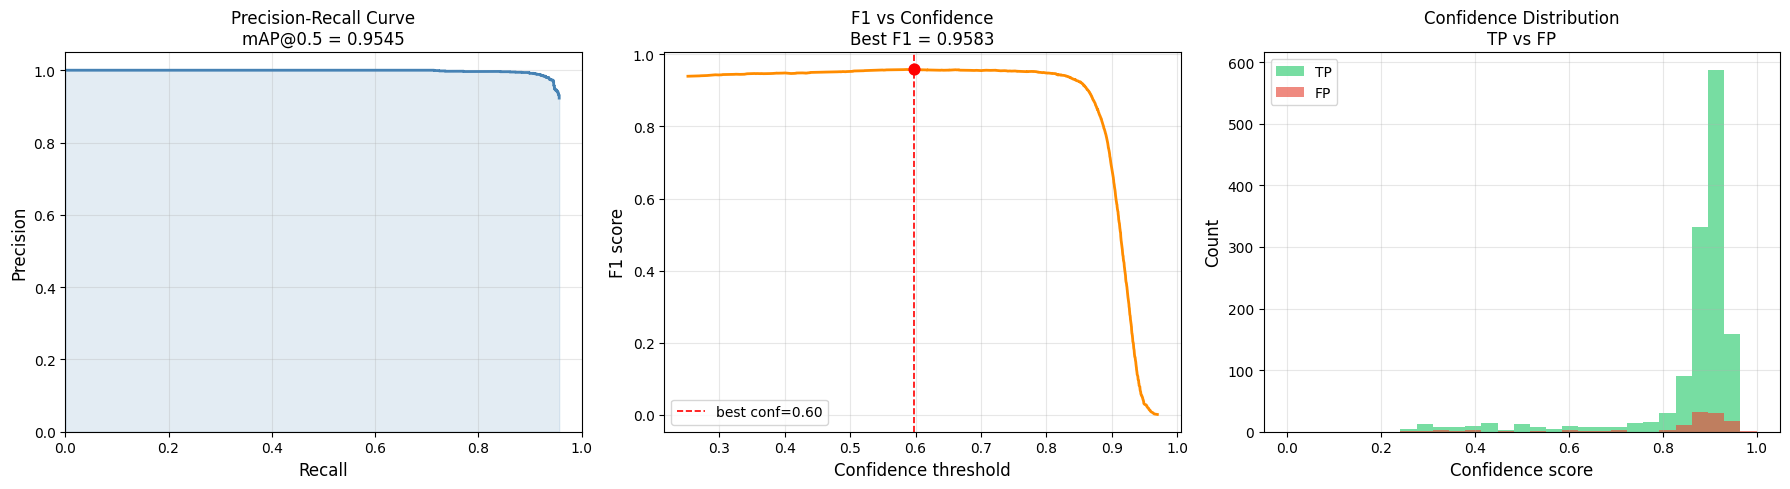

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

#  PR Curve 
ax = axes[0]
ax.plot(results['_recall_curve'], results['_precision_curve'],
        color='steelblue', linewidth=2)
ax.fill_between(results['_recall_curve'], results['_precision_curve'],
                alpha=0.15, color='steelblue')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title(f'Precision-Recall Curve\nmAP@0.5 = {results["mAP@0.5"]:.4f}', fontsize=12)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)

# F1 vs Confidence 
ax = axes[1]
conf_curve = results['_conf_curve']
f1_curve   = results['_f1_curve']
best_idx   = int(np.argmax(f1_curve))
ax.plot(conf_curve, f1_curve, color='darkorange', linewidth=2)
ax.axvline(conf_curve[best_idx], color='red', linestyle='--', linewidth=1.2,
           label=f'best conf={results["Best_Conf_Thr"]:.2f}')
ax.scatter([conf_curve[best_idx]], [f1_curve[best_idx]],
           color='red', zorder=5, s=60)
ax.set_xlabel('Confidence threshold', fontsize=12)
ax.set_ylabel('F1 score', fontsize=12)
ax.set_title(f'F1 vs Confidence\nBest F1 = {results["F1"]:.4f}', fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

#Confidence Distribution: TP vs FP 
ax = axes[2]
conf_all = results['_conf_all']
tp_all   = results['_tp_all']
tp_confs = conf_all[tp_all == 1]
fp_confs = conf_all[tp_all == 0]
bins = np.linspace(0, 1, 30)
ax.hist(tp_confs, bins=bins, alpha=0.65, color='#2ecc71', label='TP')
ax.hist(fp_confs, bins=bins, alpha=0.65, color='#e74c3c', label='FP')
ax.set_xlabel('Confidence score', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Confidence Distribution\nTP vs FP', fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_DIR / 'pr_f1_conf.png', dpi=150, bbox_inches='tight')
plt.show()

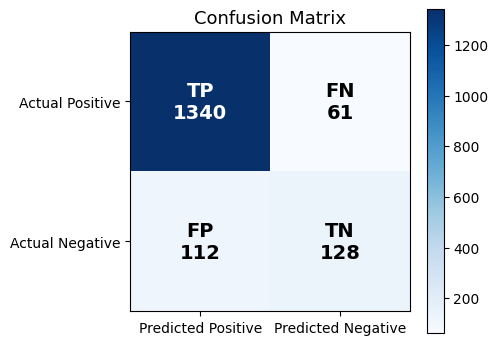

TP=1340  FP=112  FN=61  TN=128


In [23]:
tp = results['Total_TP']
fp = results['Total_FP']
fn = results['Total_FN']
tn = results['Total_TN']

cm = np.array([[tp, fn],
               [fp, tn]], dtype=np.float32)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax)

labels_cm = [['TP', 'FN'], ['FP', 'TN']]
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{labels_cm[i][j]}\n{int(cm[i,j])}',
                ha='center', va='center', fontsize=14, fontweight='bold',
                color='white' if cm[i,j] > cm.max()*0.5 else 'black')

ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Predicted Positive', 'Predicted Negative'], fontsize=10)
ax.set_yticklabels(['Actual Positive', 'Actual Negative'], fontsize=10)
ax.set_title('Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.savefig(SAVE_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'TP={tp}  FP={fp}  FN={fn}  TN={tn}')

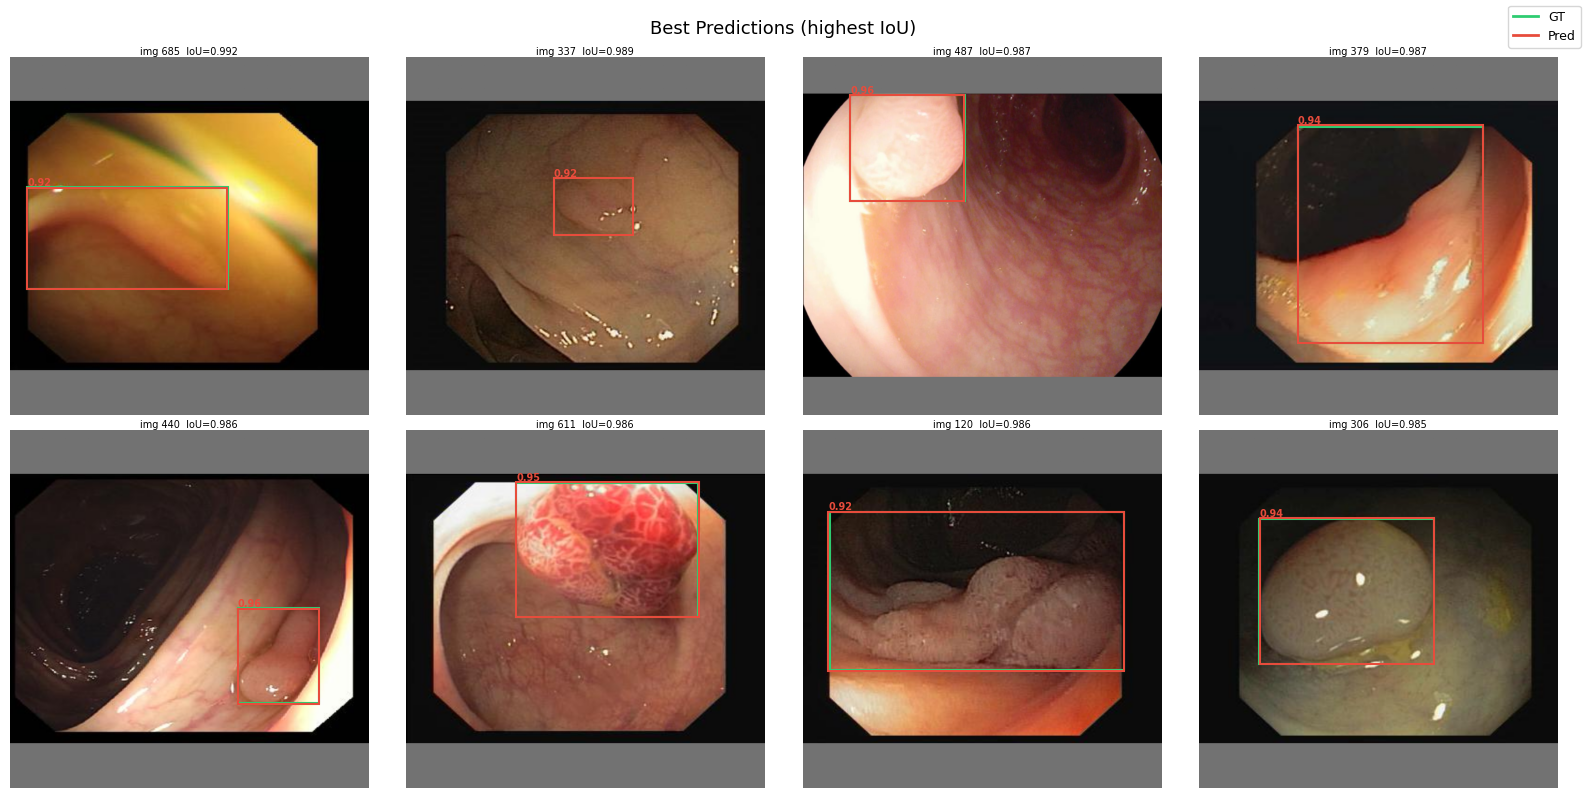

Saved best_preds.png


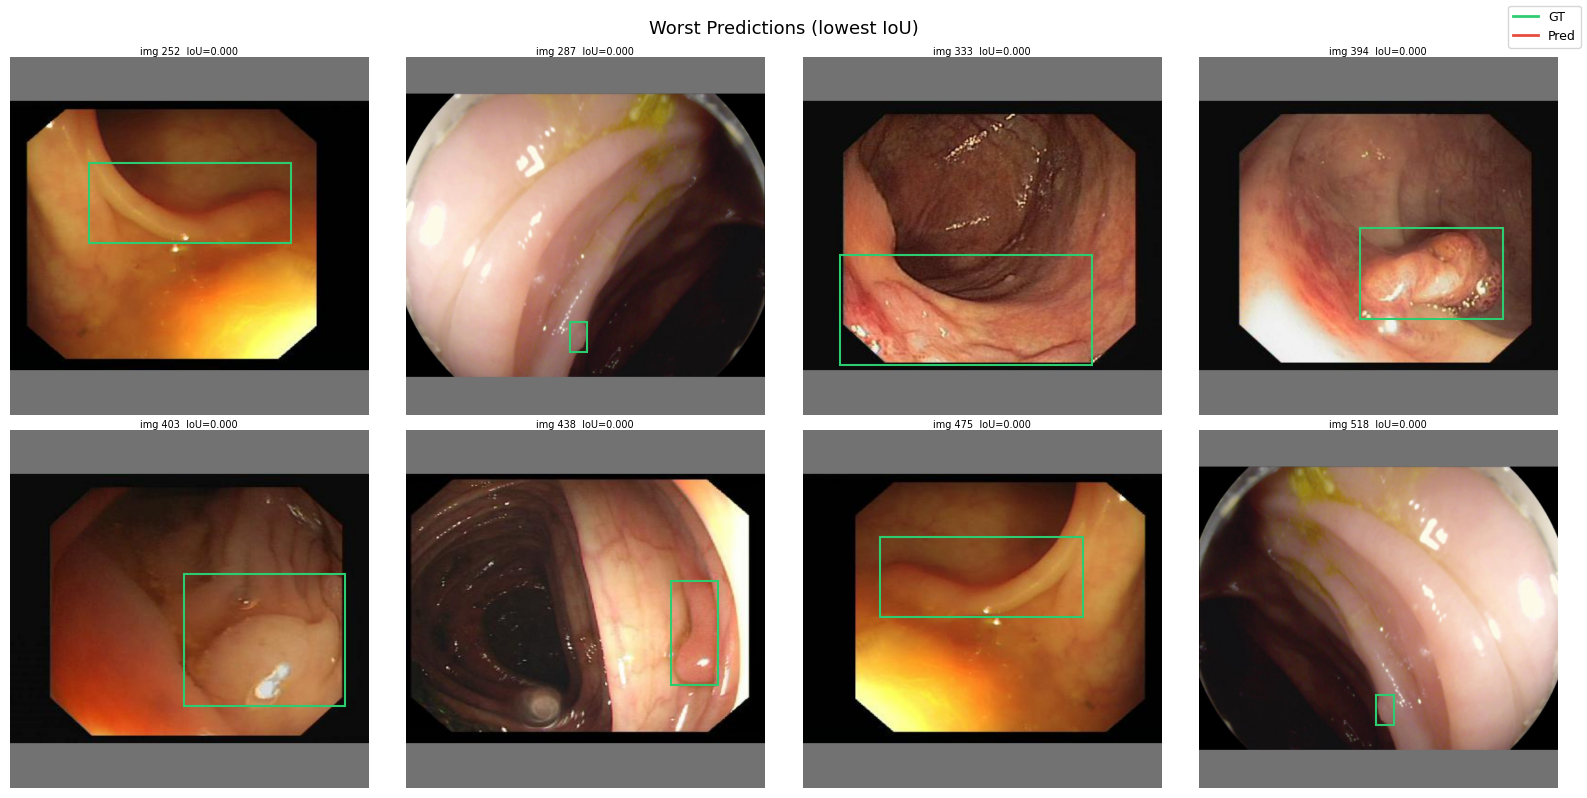

Saved worst_preds.png


In [24]:
import math
def draw_pred_gt(ax, img_tensor, pred_boxes, gt_boxes, title=''):
    """
    img_tensor : [3,H,W] float32 0-1 RGB
    pred_boxes : [N,6]  xyxy pixel (x1,y1,x2,y2,score,cls)
    gt_boxes   : [M,5]  xyxy pixel (cls,x1,y1,x2,y2)
    """
    img = img_tensor.permute(1,2,0).numpy().copy()
    ax.imshow(img)

    # GT boxes — green
    for gt in gt_boxes:
        _, x1, y1, x2, y2 = gt
        ax.add_patch(patches.Rectangle(
            (x1,y1), x2-x1, y2-y1,
            linewidth=1.5, edgecolor='#2ecc71', facecolor='none'
        ))

    # Pred boxes — red
    for pred in pred_boxes:
        x1, y1, x2, y2, score, cls = pred
        ax.add_patch(patches.Rectangle(
            (x1,y1), x2-x1, y2-y1,
            linewidth=1.5, edgecolor='#e74c3c', facecolor='none'
        ))
        ax.text(x1, y1-4, f'{score:.2f}',
                color='#e74c3c', fontsize=7, fontweight='bold')

    ax.set_title(title, fontsize=7, pad=2)
    ax.axis('off')


# rank images by max IoU of best matched detection
per_image = results['_per_image']
ranked    = sorted(
    [(i, info[3]) for i, info in enumerate(per_image) if info[1] > 0],
    key=lambda x: x[1]
)

worst_idx = [i for i,_ in ranked[:8]]
best_idx  = [i for i,_ in ranked[-8:][::-1]]

for title_str, indices, fname in [
    ('Best Predictions (highest IoU)', best_idx,  'best_preds.png'),
    ('Worst Predictions (lowest IoU)', worst_idx, 'worst_preds.png'),
]:
    n = len(indices)
    if n == 0:
        print(f'No images for {title_str}')
        continue
    cols = min(4, n)
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*4))
    axes = np.array(axes).flatten()

    for ax_i, img_i in enumerate(indices):
        draw_pred_gt(
            axes[ax_i],
            all_imgs[img_i],
            all_preds[img_i],
            all_gts[img_i],
            title=f'img {img_i}  IoU={per_image[img_i][3]:.3f}'
        )
    for ax in axes[n:]:
        ax.set_visible(False)

    # legend
    from matplotlib.lines import Line2D
    handles = [
        Line2D([0],[0], color='#2ecc71', linewidth=2, label='GT'),
        Line2D([0],[0], color='#e74c3c', linewidth=2, label='Pred'),
    ]
    fig.legend(handles=handles, loc='upper right', fontsize=9)
    fig.suptitle(title_str, fontsize=13)
    plt.tight_layout()
    plt.savefig(SAVE_DIR / fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved {fname}')



In [25]:
print('\n' + '='*50)
print('  EVALUATION SUMMARY')
print('='*50)
print(f'  Model       : {MODEL_NAME}')
print(f'  Checkpoint  : {CHECKPOINT}')
print(f'  Test images : {results["n_images"]}')
print(f'  Total GTs   : {results["n_gt_total"]}')
print(f'')
print(f'  mAP@0.5     : {results["mAP@0.5"]}')
print(f'  mAP@0.5:0.95: {results["mAP@0.5:0.95"]}')
print(f'  Precision   : {results["Precision"]}')
print(f'  Recall      : {results["Recall"]}')
print(f'  F1          : {results["F1"]}')
print(f'  Avg IoU     : {results["Avg_IoU"]}')
print(f'  Miss Rate   : {results["Miss_Rate"]}')
print(f'  FP Rate     : {results["FP_Rate"]}')
print(f'')
print(f'  Speed       : {results["speed_ms"]} ms/img  ({results["speed_fps"]} FPS)')
print('='*50)
print(f'\nAll outputs saved to: {SAVE_DIR.resolve()}')
print('  metrics.csv')
print('  pr_f1_conf.png')
print('  confusion_matrix.png')
print('  best_preds.png')
print('  worst_preds.png')


  EVALUATION SUMMARY
  Model       : yolo11n
  Checkpoint  : checkpoints_1/train/best.pt
  Test images : 1442
  Total GTs   : 1401

  mAP@0.5     : 0.9545
  mAP@0.5:0.95: 0.8146
  Precision   : 0.9728
  Recall      : 0.9443
  F1          : 0.9583
  Avg IoU     : 0.9135
  Miss Rate   : 0.0215
  FP Rate     : 0.0014

  Speed       : 0.79 ms/img  (1259.7 FPS)

All outputs saved to: D:\vinod_FYP\checkpoints_1\eval
  metrics.csv
  pr_f1_conf.png
  confusion_matrix.png
  best_preds.png
  worst_preds.png
